# P16 — Recurrent Networks (RNN / LSTM / GRU)  *(we give the mind memory… and find why it wasn't enough)*

> **The story so far.** In P15 we gave the mind **eyes**: it learned to feel edges, fold them into
> shapes, and name the things they make — anywhere in a picture. But a photo is frozen in the *now*.
> CNNs see; they do not *remember*. To read a sentence, hum a tune, or follow a story, the mind needs
> to hold onto what came before. So in this chapter **we give the mind memory** — a little inner
> note it updates with every new word it hears. And then we make a quiet, important discovery: this
> first kind of memory *fades*, and that fading is the ache that will summon **attention**.

Listen to yourself finish someone's sentence. You're not weighing each word in isolation; you carry a
running sense of the sentence *so far*, and each new word nudges it. A model that works this way —
read one element at a time, update a carried-forward summary — is a **Recurrent Neural Network
(RNN)**. We build an RNN cell by hand and watch its memory accumulate, then expose its fatal flaw:
across long stretches it *forgets* (the vanishing-gradient problem of P13, now playing out over
*time*). That precise pain is what **attention** (the next notebooks) was invented to end — so this
chapter is the conceptual bridge into transformers and the TinyGPT track.

## B1 — The RNN cell: one recurrence, applied at every time step

Think of the mind reading aloud with a single sticky note in hand. Each word it reads, it scribbles
an updated summary on that one note — never a fresh note, always the same one, rewritten. That note
is the **hidden state** `h`: the mind's memory. At each step the RNN combines the new input `xₜ` with
the previous note `hₜ₋₁` to produce the new note:
```
hₜ = tanh( Wₓ·xₜ + Wₕ·hₜ₋₁ + b )
```
The *same* weights `Wₓ, Wₕ` are reused at every step (weight sharing across time, like CNNs share
across space). The final `h` is a summary of the whole sequence.

**Worked example by hand** (scalars, to keep it traceable). `Wₓ=0.5, Wₕ=0.9, b=0`, start `h₀=0`,
input sequence `x = [1, 1, 1]`:
```
h₁ = tanh(0.5·1 + 0.9·0) = tanh(0.5)  = 0.462
h₂ = tanh(0.5·1 + 0.9·0.462) = tanh(0.916) = 0.724
h₃ = tanh(0.5·1 + 0.9·0.724) = tanh(1.152) = 0.818
```
The state accumulates information from earlier steps through `hₜ₋₁`.

In [1]:
import numpy as np
Wx, Wh, b = 0.5, 0.9, 0.0
h = 0.0
for t, x in enumerate([1.0, 1.0, 1.0], 1):
    h = np.tanh(Wx*x + Wh*h + b)
    print(f"h{t} = tanh({Wx}*{x} + {Wh}*h_prev) = {h:.3f}")
print("hand: 0.462, 0.724, 0.818  -> the hidden state carries the past forward")

h1 = tanh(0.5*1.0 + 0.9*h_prev) = 0.462
h2 = tanh(0.5*1.0 + 0.9*h_prev) = 0.724
h3 = tanh(0.5*1.0 + 0.9*h_prev) = 0.818
hand: 0.462, 0.724, 0.818  -> the hidden state carries the past forward


## B2 — A real (vectorised) RNN processing a sequence

A one-number sticky note is fine for a story; real language needs a richer note — a whole vector of
remembered things. With vector states and matrix weights it's the *same* recurrence, just bigger.
Here a small RNN reads a sequence of 5 input-vectors and updates its note at each step. Watch the
**loop over time**: the mind cannot peek at word 5 before it has read words 1–4. RNNs are inherently
*sequential* — and that, foreshadowing, is one reason transformers (which read a whole sentence at
once) eventually overtook them.

In [2]:
import numpy as np
rng = np.random.default_rng(0)
T, d_in, d_hid = 5, 3, 4
Wx = rng.normal(0, 0.5, (d_hid, d_in))
Wh = rng.normal(0, 0.5, (d_hid, d_hid))
b  = np.zeros(d_hid)
xs = rng.normal(size=(T, d_in))               # a sequence of 5 vectors

h = np.zeros(d_hid)
print("processing sequence one step at a time:")
for t in range(T):
    h = np.tanh(Wx @ xs[t] + Wh @ h + b)
    print(f"  step {t}: hidden state = {np.round(h, 3)}")
print("final hidden state summarises the whole sequence.")

processing sequence one step at a time:
  step 0: hidden state = [-0.351 -0.259  0.16   0.197]
  step 1: hidden state = [ 0.41   0.382 -0.519 -0.127]
  step 2: hidden state = [-0.352 -0.498  0.727  0.192]
  step 3: hidden state = [ 0.344  0.444 -0.644 -0.587]
  step 4: hidden state = [ 0.397 -0.681 -0.183  0.777]
final hidden state summarises the whole sequence.


## B3 — The wall: vanishing gradients over time = forgetting

Here is where the single sticky note betrays the mind. Try to keep a thread across a long sentence —
"The **cat** that the dog that the neighbour owned chased … **was** hungry" — and by the time it
reaches *was*, the memory of *cat* has been overwritten dozens of times. Mathematically: to learn
such a long-range link, the gradient must travel back across many time steps, and
backprop-through-time multiplies by `Wₕ` (and `tanh'<1`) at *every* step — so the influence of
distant inputs shrinks geometrically toward zero. The mind effectively **forgets** anything more than
a handful of steps back. This is the wall.

We show it: track how much the final state depends on the *first* input as the sequence lengthens.

In [3]:
import numpy as np
Wh = 0.9   # |Wh|<1 and tanh'<1  -> influence decays each step
print("how much does h_T still 'remember' the first step's signal?")
for T in [1, 5, 10, 20, 40]:
    # rough influence of step 0 on step T  ~  (Wh * tanh'~0.6)^T
    influence = (Wh * 0.6)**T
    print(f"  sequence length {T:>2}: remaining influence of step 0 ≈ {influence:.2e}")
print("\nby ~20 steps the early signal has all but vanished -> RNNs can't hold long-range context.")

how much does h_T still 'remember' the first step's signal?
  sequence length  1: remaining influence of step 0 ≈ 5.40e-01
  sequence length  5: remaining influence of step 0 ≈ 4.59e-02
  sequence length 10: remaining influence of step 0 ≈ 2.11e-03
  sequence length 20: remaining influence of step 0 ≈ 4.45e-06
  sequence length 40: remaining influence of step 0 ≈ 1.98e-11

by ~20 steps the early signal has all but vanished -> RNNs can't hold long-range context.


## B4 — LSTM & GRU: gates that choose what to remember

If one sticky note keeps getting overwritten, give the mind a *second*, protected notebook — and
little valves that decide what to copy into it, what to leave untouched, and what to read out. That
is the **LSTM** (Long Short-Term Memory): it patches the forgetting problem with a separate **cell
state** and learnable **gates** that choose what to keep, forget, and output:
```
forget gate  fₜ = σ(...)    how much old memory to keep
input gate   iₜ = σ(...)    how much new info to write
output gate  oₜ = σ(...)    how much memory to expose
cell state   cₜ = fₜ·cₜ₋₁ + iₜ·c̃ₜ      (the key: a near-direct path for memory)
```
The cell state's additive update (`fₜ·cₜ₋₁ + …`) is a **gradient highway over time** — the same
trick as residual connections (P13 B5) — so LSTMs remember much longer. **GRUs** are a simpler,
faster variant with two gates instead of three. Both were the workhorses of NLP *before*
transformers. We show the gate idea with a tiny forget-gate demo rather than a full cell.

In [4]:
import numpy as np
def sigmoid(z): return 1/(1+np.exp(-z))
# a forget gate near 1 keeps memory; near 0 erases it
c_prev = 5.0                               # old memory value
for forget_logit in [3.0, 0.0, -3.0]:
    f = sigmoid(forget_logit)
    c_new = f*c_prev                       # (ignoring the input-write term for clarity)
    print(f"forget gate = σ({forget_logit:+.0f}) = {f:.3f}  ->  memory {c_prev} kept as {c_new:.2f}")
print("\na learnable gate near 1 PRESERVES the cell state across many steps -> long memory.")

forget gate = σ(+3) = 0.953  ->  memory 5.0 kept as 4.76
forget gate = σ(+0) = 0.500  ->  memory 5.0 kept as 2.50
forget gate = σ(-3) = 0.047  ->  memory 5.0 kept as 0.24

a learnable gate near 1 PRESERVES the cell state across many steps -> long memory.


In [ ]:
# === READ-ONLY — illustrative library code, not executed here ===
# In practice you'd just call the library cell (read-only sketch):
import torch.nn as nn
lstm = nn.LSTM(input_size=3, hidden_size=4, num_layers=1, batch_first=True)
# out, (h_n, c_n) = lstm(sequence)   # PyTorch handles the gates & time loop for you
# Keras equivalent: keras.layers.LSTM(4)

## B5 — Why attention had to be invented (the bridge to transformers)

The gated notebook helps the mind remember longer — but it never truly cures the ache. Even LSTMs
have two stubborn limits:
1. **Sequential computation** — they process one step at a time, so they can't exploit modern
   parallel hardware well (slow to train on long sequences).
2. **A single fixed-size memory** — everything seen must be crammed into one hidden vector, a
   bottleneck for long, complex context.

**Attention** (Notebook 00 B9, built fully in `notebooks/04`) removes both: every position can look
*directly* at every other position in one parallel operation — no decay over distance, no single
bottleneck, no sequential loop. That idea, scaled up, *is* the transformer. You've now seen exactly
the problem it solves, so the attention notebooks will land with full motivation.

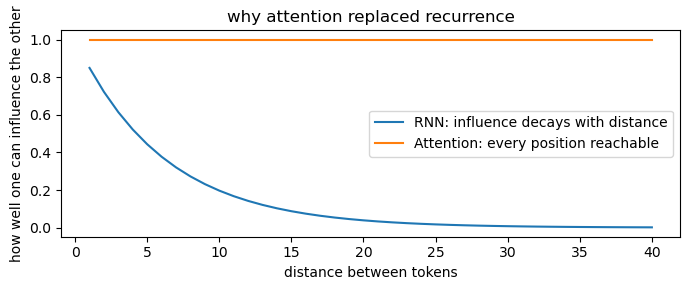

attention gives constant-distance access — the core advantage transformers are built on.


In [5]:
# the contrast in one picture (conceptual): RNN reach decays with distance; attention is flat
import numpy as np, matplotlib.pyplot as plt
dist = np.arange(1, 41)
rnn_reach = (0.85)**dist                      # information decays with distance
attn_reach = np.ones_like(dist, dtype=float)  # every position reachable equally
plt.figure(figsize=(7,3))
plt.plot(dist, rnn_reach, label="RNN: influence decays with distance")
plt.plot(dist, attn_reach, label="Attention: every position reachable")
plt.xlabel("distance between tokens"); plt.ylabel("how well one can influence the other")
plt.legend(); plt.title("why attention replaced recurrence"); plt.tight_layout(); plt.show()
print("attention gives constant-distance access — the core advantage transformers are built on.")

## Recap — sequence models and their limits

| Model | Memory mechanism | Limit |
|-------|------------------|-------|
| Vanilla RNN | hidden state recurrence | forgets fast (vanishing gradient) |
| LSTM | cell state + 3 gates | remembers longer, but still sequential |
| GRU | 2 gates (simpler LSTM) | faster, similar idea |
| **Attention** (next) | direct all-to-all access | parallel, no decay → transformers |

## Common mistakes
1. **Expecting a vanilla RNN to learn long-range patterns.** It physically can't; use LSTM/GRU or attention.
2. **Forgetting RNNs are sequential** — you can't parallelise across time within one sequence (a real speed cost).
3. **Confusing hidden state with cell state** in LSTMs — the cell state is the long-term highway; the hidden state is the exposed output.
4. **Not initialising the hidden state** (it starts at zeros) — and carrying it across batches incorrectly.
5. **Reaching for RNNs in 2020s NLP.** Transformers dominate; RNNs remain useful for tiny/streaming/low-latency cases.

## Exercises (do them in new code cells)
1. Continue B1 for `h₄, h₅` with the same inputs. Does `h` approach a steady value? Why (tanh saturates)?
2. In B3, set `Wh=1.05`. Does the influence now vanish or *explode* with length? Relate to P13.
3. Show that a forget gate of exactly 1.0 preserves memory perfectly across 100 steps (B4).
4. Why can a transformer process all positions in parallel while an RNN cannot? (Point to the recurrence.)
5. Name one real scenario where an RNN/LSTM might still be preferable to a transformer, and why.

---

**Part 2 (Deep Learning) is complete — and the mind now has eyes *and* memory.** It can build,
train, debug, and scale a brain, and it has felt firsthand why a single fading thread of memory was
never going to be enough. That longing — *let me look back at anything I've seen, without it
decaying* — is the exact wish attention will grant. But before the mind can read with attention, it
must first learn to read *at all*. Next, in **Part 3 — Language**, we sit it down for its clumsy
first reading lessons: [P17 — Classical NLP](P17_Classical_NLP.ipynb), where it learns to handle text
the old way — by *counting words* — and we watch it miss the meaning entirely. Then words become
*places* (P18), it learns to **pay attention** (P19), and the bridge hands off to TinyGPT (P20).